This project performs a comprehensive analysis of Apple Inc. (AAPL) stock prices using Python. It includes historical data visualization, candlestick charts, moving averages, and price prediction using a simple machine learning model.


In [2]:
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.2 MB/s eta 0:00:00


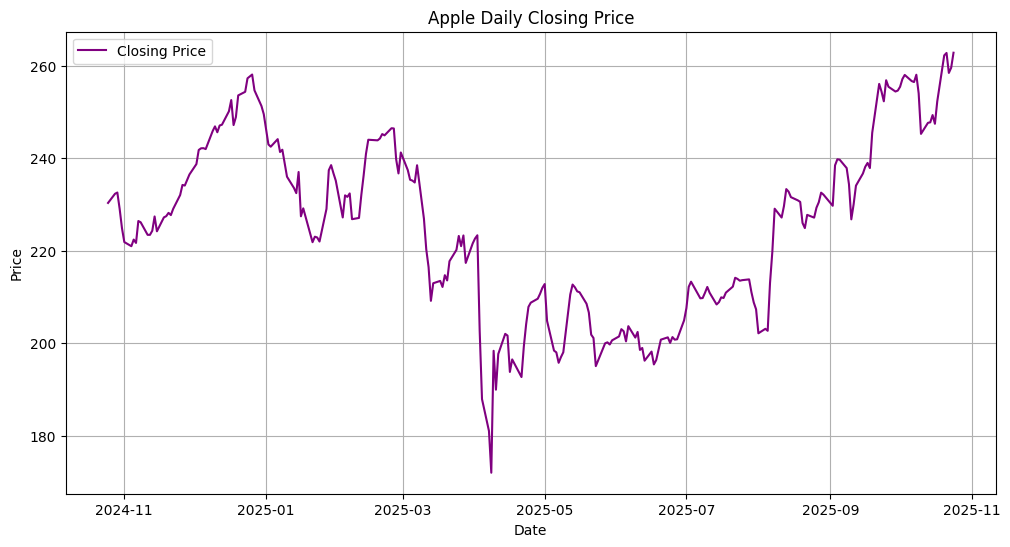

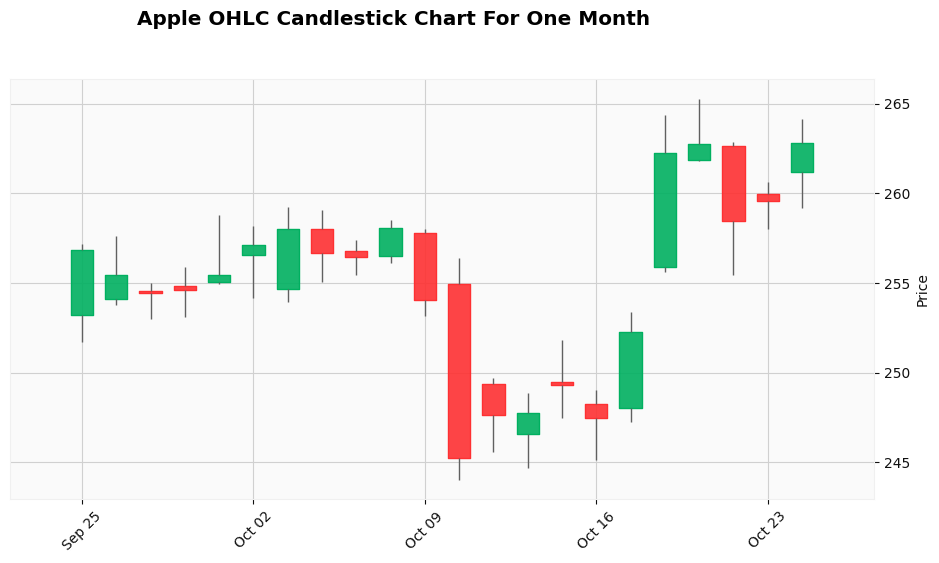

In [3]:
import yfinance as yf
import mplfinance as mpf
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

### code for line chart
apple = yf.Ticker("AAPL")
history = apple.history(period="1y", interval='1d')
history = history.reset_index()
history['Date_Numeric'] = mdates.date2num(history['Date'])
plt.figure(figsize=(12,6))
plt.plot(history['Date'], history['Close'], color='purple', label='Closing Price')
plt.title('Apple Daily Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

### Below is the code for Candlestick Chart for one month to make the chart look clear
one_month_history = yf.Ticker("AAPL").history(period='1mo', interval='1d')
one_month_history.index.name = 'Date'
mpf.plot(one_month_history, type='candle', style='yahoo', volume=False, figsize=(12,6), title='Apple OHLC Candlestick Chart For One Month', ylabel='Price')

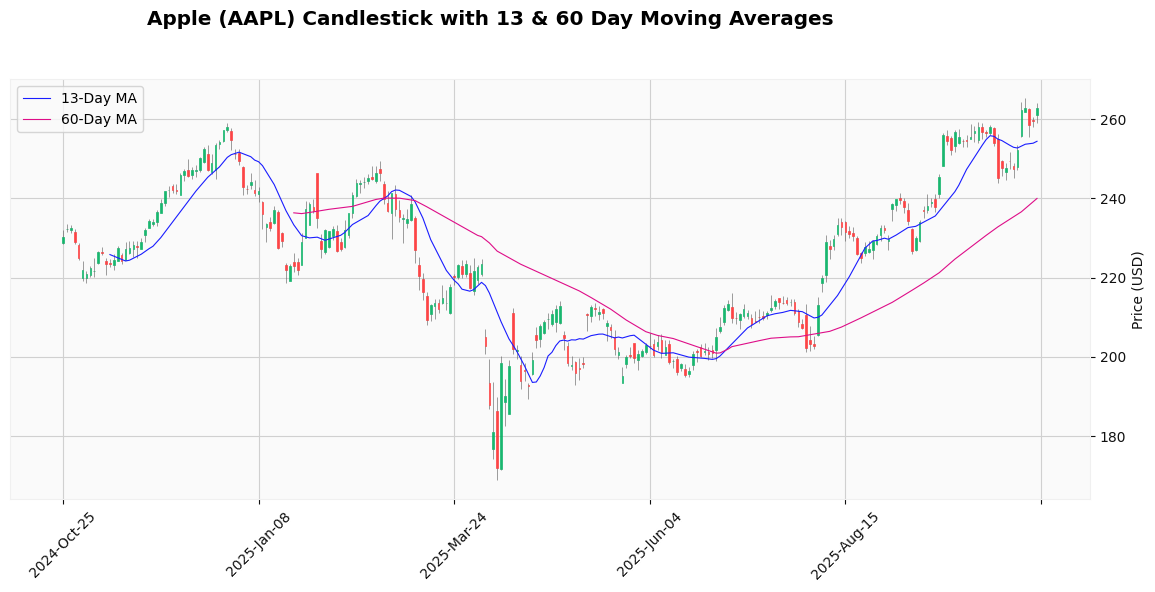

In [4]:
### Stock analysis MA

import yfinance as yf
import matplotlib.pyplot as plt
import mplfinance as mpf

apple = yf.Ticker("AAPL")
data = apple.history(period="1y", interval="1d")
data['SMA_13'] = data['Close'].rolling(window=13).mean()
data['SMA_60'] = data['Close'].rolling(window=60).mean()

add_plots = [
    mpf.make_addplot(data['SMA_13'], color='#1A1DFF', width=0.8, label='13-Day MA'),
    mpf.make_addplot(data['SMA_60'], color='#DE0D88', width=0.8, label='60-Day MA')
]

mpf.plot(
    data,
    type='candle',
    style='yahoo',
    addplot=add_plots,
    volume=False,
    figsize=(15,6),
    title='Apple (AAPL) Candlestick with 13 & 60 Day Moving Averages',
    ylabel='Price (USD)'
)

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from datetime import datetime

data = yf.download('AAPL', start='2023-01-01', end='2025-09-21')  # till day before prediction
data = data[['Close']]
data.reset_index(inplace=True)

# Convert dates to numeric format
# This allows the model to understand the passage of time
data['Date_Num'] = (data['Date'] - data['Date'].min()).dt.days
data['MA_5'] = data['Close'].rolling(window=5).mean()
data['MA_20'] = data['Close'].rolling(window=20).mean()
data['MA_diff'] = (data['MA_5'] - data['MA_20'])

# Remove rows with missing values (NaNs created by rolling MAs)
data.dropna(inplace=True)

# Prepare features (inputs(X)) and target (output(Y))
X = data[['Date_Num', 'MA_5', 'MA_20', 'MA_diff']]
y = data['Close']

# Train model
model = LinearRegression()
model.fit(X, y)

# Make a prediction for a future date
predict_date = pd.to_datetime('2025-09-22')

# Convert prediction date to numeric
predict_day_num = (predict_date - data['Date'].min()).days

# Use the latest MA values for the prediction
last_ma5 = data['MA_5'].iloc[-1]
last_ma20 = data['MA_20'].iloc[-1]
last_ma_diff = last_ma5 - last_ma20

# Predict
predicted_price = model.predict([[predict_day_num,last_ma5, last_ma20, last_ma_diff ]])
print(f"Predicted AAPL closing price on 2025-09-22: ${float(predicted_price[0]):.2f}")

/tmp/ipython-input-1996169637.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2023-01-01', end='2025-09-21')  # till day before prediction
[*********************100%***********************]  1 of 1 completed

Predicted AAPL closing price on 2025-09-22: $240.11



/tmp/ipython-input-1996169637.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Predicted AAPL closing price on 2025-09-22: ${float(predicted_price[0]):.2f}")
